In [29]:
# =============================================================================
# Standard Library
# =============================================================================
import os
from pathlib import Path

# =============================================================================
# Data Processing
# =============================================================================
import pandas as pd
import numpy as np

# =============================================================================
# Pandas Display Configuration
# =============================================================================
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# =============================================================================
# Reproducibility
# =============================================================================
SEED = 42
np.random.seed(SEED)

# =============================================================================
# Data Visualization
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Files
questions = pd.read_csv(r"C:\Users\Admin\Desktop\Digilians\Second Term\AI Applied and Tools\RAG\multi_questions.csv")
answers = pd.read_csv(r"C:\Users\Admin\Desktop\Digilians\Second Term\AI Applied and Tools\RAG\multi_answers.csv")

In [3]:
# Check Shape
print("Questions Shape:")
print(questions.shape)

print("\nAnswers Shape:")
print(answers.shape)

Questions Shape:
(172617, 6)

Answers Shape:
(4019744, 6)


In [4]:
# Check Columns
questions.head()

,QuestionID,QuestionType,Category,AskerID,QuestionTime,QuestionText
0,C1Q1,yes/no,Automotive,A365S8H55GGXPD,"July 19, 2013",will they fit 2013 f350 dually
1,C1Q2,yes/no,Automotive,AXOOEUYEJ87ZB,"May 7, 2014",will they fit 2014 mazda 3 sport?
2,C1Q3,open-ended,Automotive,AN2AMELSNPN99,"June 20, 2014",Do they fit a 1998 GMC Sierra 3 door?
3,C1Q4,yes/no,Automotive,A367QVRWPWFTLT,"September 3, 2013",will this work on 95 bonneville and 94 camaro
4,C1Q5,yes/no,Automotive,A15Q5XTXEKWK0E,"November 3, 2013",will this fit a 1996 4 winns 238 vista 5.0 w/volvo sx drive?


In [5]:
questions["QuestionTime"].head(20)

0         July 19, 2013
1           May 7, 2014
2         June 20, 2014
3     September 3, 2013
4      November 3, 2013
5        March 23, 2014
6     February 22, 2014
7         March 7, 2014
8         March 3, 2014
9        April 18, 2014
10         July 6, 2013
11         May 19, 2014
12         June 4, 2014
13       March 27, 2013
14         May 17, 2014
15    December 17, 2013
16     February 5, 2015
17    November 12, 2014
18       April 23, 2014
19     January 14, 2014
Name: QuestionTime, dtype: str

In [6]:
questions["QuestionTime"].sample(20, random_state=42)

152379       October 9, 2014
125675     December 30, 2013
18120       November 9, 2012
130991          June 5, 2014
145243        April 24, 2015
63183      February 16, 2014
112118     February 24, 2013
117693       October 4, 2013
64834          June 23, 2006
8838      September 17, 2013
166383         July 13, 2014
158881      January 24, 2014
138377     December 18, 2014
33932        August 27, 2013
16929     September 13, 2013
42572       October 18, 2013
39359        August 29, 2014
3493        November 2, 2013
72742         April 16, 2013
114396     November 15, 2014
Name: QuestionTime, dtype: str

In [7]:
# ابحثي عن القيم غير الصالحة
invalid_dates = pd.to_datetime(
    questions["QuestionTime"],
    errors="coerce")

questions.loc[invalid_dates.isna(),"QuestionTime"].unique()[:20]

<StringArray>
[          'da Waller',   'draw something...',           '60s Music',
            'the moon',              'the go',             'twitter',
                'Call',              'Amazon',             'the run',
               'Earth',           'the beach',            'anything',
             'crochet',   'Martha's Vineyard',       'Manufacturers',
    'this snowy day!!', 'on December 8, 2014',                  '$0',
               'birds']
Length: 19, dtype: str

In [8]:
# =============================================================================
# Count invalid dates in QuestionTime
# =============================================================================

invalid_dates = pd.to_datetime(questions["QuestionTime"], errors="coerce").isna()

invalid_count = invalid_dates.sum()

total_rows = len(questions)

invalid_percentage = (invalid_count / total_rows) * 100

print(f"Invalid rows      : {invalid_count}")
print(f"Total rows        : {total_rows}")
print(f"Invalid Percentage: {invalid_percentage:.4f}%")

Invalid rows      : 38
Total rows        : 172617
Invalid Percentage: 0.0220%


In [9]:
# =============================================================================
# Remove rows with invalid dates
# =============================================================================

questions = questions.loc[~invalid_dates].copy()

questions["QuestionTime"] = pd.to_datetime(questions["QuestionTime"])

questions.reset_index(drop=True, inplace=True)

In [10]:
# Check Columns
answers.head()

,QuestionID,AnswerText,AnswererID,AnswerTime,AnswerType,AnswerScore
0,C1Q1,"It's all custom mounting, where there's a will there's a way, don't see why not, figure 15minutes per mud flap, there isn't any hardware included just the stamped sheet metal pieces",AQZ8QLPPYA359,"December 29, 2014",NaN,NaN
1,C1Q1,"You will need to drill another hole in Mud flap & bed frame for added stability. the added bolt & nut makes it a tighter fit, you only get two existing holes on the bed frame with plastic mud fla...",A246IDL7UXVCQO,"December 29, 2014",NaN,NaN
2,C1Q1,"It's been a while since I installed them, but I don't think any installation hardware is included.",A3BWPG98KF0TAV,"July 19, 2013",?,0.5428
3,C1Q1,1 pair rear flaps and mounting hardware.,1,"July 19, 2013",?,0.5565
4,C1Q1,I didn't buy these for myself I bought them for our son-in-law for a Christmas gift but I think they came with the hardware.,A1MGZTOLD2C0VS,"July 19, 2013",?,0.4623


In [11]:
# Dataset Information
questions.info()

<class 'pandas.DataFrame'>
RangeIndex: 172579 entries, 0 to 172578
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   QuestionID    172579 non-null  str           
 1   QuestionType  172579 non-null  str           
 2   Category      172579 non-null  str           
 3   AskerID       172579 non-null  str           
 4   QuestionTime  172579 non-null  datetime64[us]
 5   QuestionText  172579 non-null  str           
dtypes: datetime64[us](1), str(5)
memory usage: 7.9 MB


In [12]:
# Dataset Information
answers.info()

<class 'pandas.DataFrame'>
RangeIndex: 4019744 entries, 0 to 4019743
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   QuestionID   str    
 1   AnswerText   str    
 2   AnswererID   str    
 3   AnswerTime   str    
 4   AnswerType   str    
 5   AnswerScore  float64
dtypes: float64(1), str(5)
memory usage: 184.0 MB


In [13]:
# Data Cleaning
questions["QuestionText"] = questions["QuestionText"].astype("string")
questions["QuestionType"] = questions["QuestionType"].astype("category")
questions["Category"] = questions["Category"].astype("category")
questions["QuestionTime"] = pd.to_datetime(questions["QuestionTime"])

answers["AnswerText"] = answers["AnswerText"].astype("string")
answers["AnswerType"] = answers["AnswerType"].astype("category")
answers["AnswerTime"] = pd.to_datetime(answers["AnswerTime"])
answers["AnswerScore"] = answers["AnswerScore"].astype("float32")

In [14]:
# Dataset Information
questions.info()

<class 'pandas.DataFrame'>
RangeIndex: 172579 entries, 0 to 172578
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   QuestionID    172579 non-null  str           
 1   QuestionType  172579 non-null  category      
 2   Category      172579 non-null  category      
 3   AskerID       172579 non-null  str           
 4   QuestionTime  172579 non-null  datetime64[us]
 5   QuestionText  172579 non-null  string        
dtypes: category(2), datetime64[us](1), str(2), string(1)
memory usage: 5.6 MB


In [15]:
# Dataset Information
answers.info()

<class 'pandas.DataFrame'>
RangeIndex: 4019744 entries, 0 to 4019743
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   QuestionID   str           
 1   AnswerText   string        
 2   AnswererID   str           
 3   AnswerTime   datetime64[us]
 4   AnswerType   category      
 5   AnswerScore  float32       
dtypes: category(1), datetime64[us](1), float32(1), str(2), string(1)
memory usage: 141.8 MB


In [16]:
# Merge
dataset = questions.merge(answers,on="QuestionID", how="inner")

In [17]:
# Check Columns
dataset.head()

,QuestionID,QuestionType,Category,AskerID,QuestionTime,QuestionText,AnswerText,AnswererID,AnswerTime,AnswerType,AnswerScore
0,C1Q1,yes/no,Automotive,A365S8H55GGXPD,2013-07-19,will they fit 2013 f350 dually,"It's all custom mounting, where there's a will there's a way, don't see why not, figure 15minutes per mud flap, there isn't any hardware included just the stamped sheet metal pieces",AQZ8QLPPYA359,2014-12-29,NaN,NaN
1,C1Q1,yes/no,Automotive,A365S8H55GGXPD,2013-07-19,will they fit 2013 f350 dually,"You will need to drill another hole in Mud flap & bed frame for added stability. the added bolt & nut makes it a tighter fit, you only get two existing holes on the bed frame with plastic mud fla...",A246IDL7UXVCQO,2014-12-29,NaN,NaN
2,C1Q1,yes/no,Automotive,A365S8H55GGXPD,2013-07-19,will they fit 2013 f350 dually,"It's been a while since I installed them, but I don't think any installation hardware is included.",A3BWPG98KF0TAV,2013-07-19,?,0.5428
3,C1Q1,yes/no,Automotive,A365S8H55GGXPD,2013-07-19,will they fit 2013 f350 dually,1 pair rear flaps and mounting hardware.,1,2013-07-19,?,0.5565
4,C1Q1,yes/no,Automotive,A365S8H55GGXPD,2013-07-19,will they fit 2013 f350 dually,I didn't buy these for myself I bought them for our son-in-law for a Christmas gift but I think they came with the hardware.,A1MGZTOLD2C0VS,2013-07-19,?,0.4623


In [18]:
print(dataset.shape)

(4018879, 11)


In [19]:
# Data Quality Check
# Missing Values Count & Percentage
missing = pd.DataFrame({
    "Missing Values": dataset.isnull().sum(),
    "Missing Percentage (%)": (dataset.isnull().sum() / len(dataset) * 100).round(2)})

# Display only columns with missing values
missing = missing[missing["Missing Values"] > 0]

missing.sort_values(by="Missing Percentage (%)", ascending=False)

,Missing Values,Missing Percentage (%)
AnswerType,3418261,85.06
AnswerScore,3418261,85.06
AnswerText,174,0.00


In [20]:
# Remove rows with missing AnswerText and AnswerTime
dataset = dataset.dropna(subset=["AnswerText"])

# Drop AnswerType and AnswerScore (80% missing)
dataset = dataset.drop(columns=["AnswerType","AnswerScore"])

In [21]:
print(dataset.shape)

(4018705, 9)


In [22]:
# Duplicate Questions
# Duplicate Check
dataset.duplicated().sum()

np.int64(21314)

In [23]:
# Drop Duplicate
dataset = dataset.drop_duplicates()

In [24]:
# Duplicate Check
dataset.duplicated().sum()

np.int64(0)

In [25]:
# EDA
# Calculate the number of words in each question
dataset["question_length"] = (dataset["QuestionText"].apply(lambda x: len(str(x).split())))

In [26]:
# Calculate the number of words in each answer
dataset["answer_length"] = (dataset["AnswerText"].apply(lambda x: len(str(x).split())))

In [27]:
# Summary statistics for question and answer lengths
dataset[["question_length", "answer_length"]].describe()

,question_length,answer_length
count,3.997391e+06,3.997391e+06
mean,1.576860e+01,3.464913e+01
std,2.744436e+01,7.339327e+01
min,1.000000e+00,1.000000e+00
25%,7.000000e+00,8.000000e+00
50%,1.100000e+01,1.900000e+01
75%,1.900000e+01,3.600000e+01
max,3.313000e+03,5.464000e+03


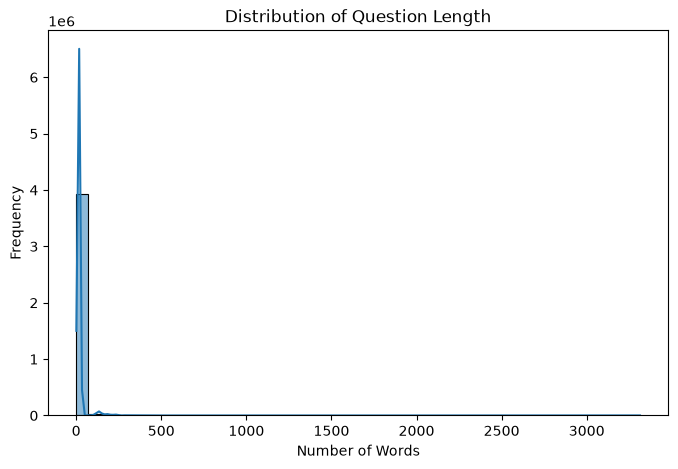

In [30]:
# Plot the distribution of question lengths
plt.figure(figsize=(8, 5))

sns.histplot(
    data=dataset,
    x="question_length",
    bins=50,
    kde=True)

plt.title("Distribution of Question Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

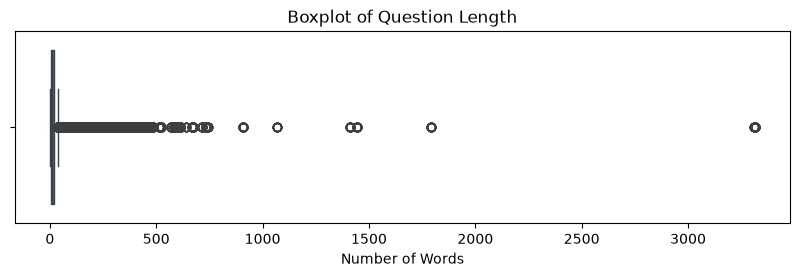

In [33]:
# =============================================================================
# Plot a boxplot of question lengths
# =============================================================================

plt.figure(figsize=(10, 2.5))

sns.boxplot(
    data=dataset,
    x="question_length")

plt.title("Boxplot of Question Length")
plt.xlabel("Number of Words")

plt.show()

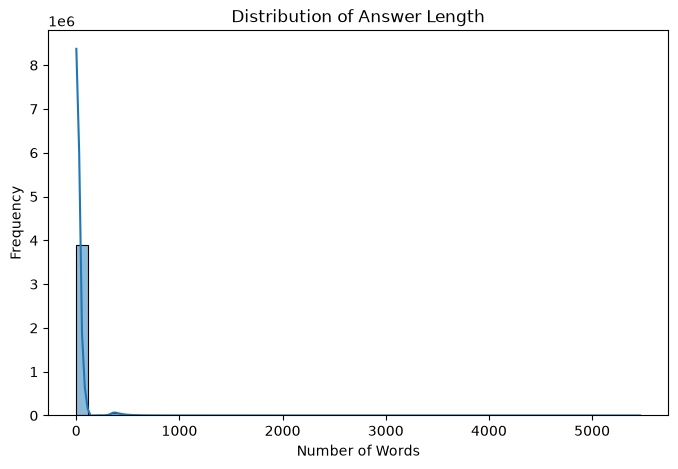

In [31]:
# Plot the distribution of answer lengths
plt.figure(figsize=(8, 5))

sns.histplot(
    data=dataset,
    x="answer_length",
    bins=50,
    kde=True)

plt.title("Distribution of Answer Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

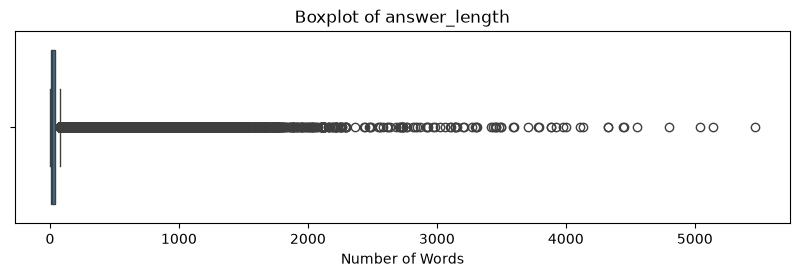

In [34]:
# =============================================================================
# Plot a boxplot of question lengths
# =============================================================================

plt.figure(figsize=(10, 2.5))

sns.boxplot(
    data=dataset,
    x="answer_length")

plt.title("Boxplot of answer_length")
plt.xlabel("Number of Words")

plt.show()

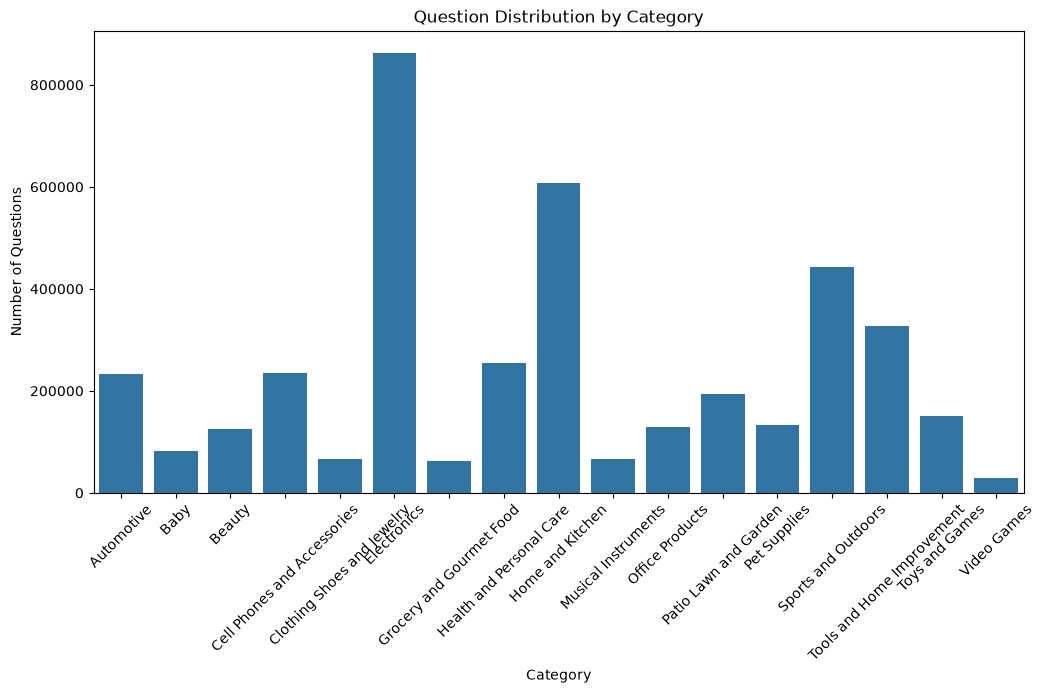

In [35]:
# Count the number of questions in each category
category_counts = dataset["Category"].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values)

plt.title("Question Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Questions")

plt.xticks(rotation=45)

plt.show()

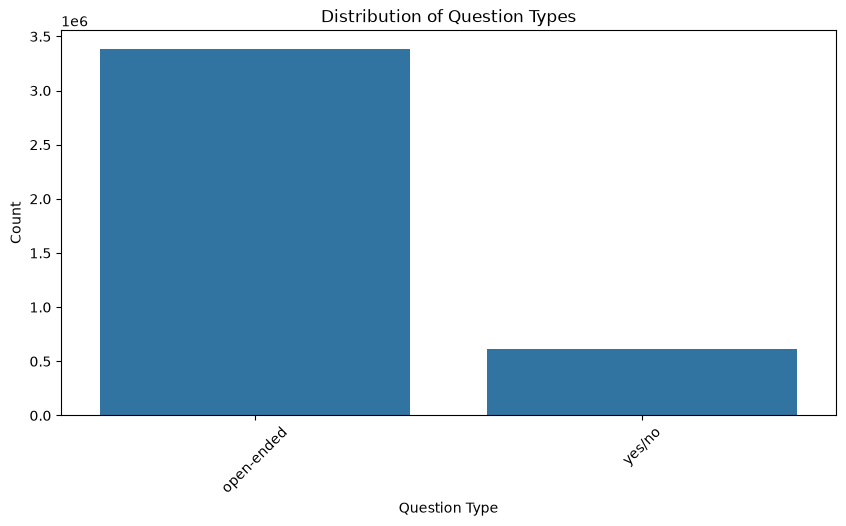

In [38]:
# Count the number of questions by question type
question_type_counts = dataset["QuestionType"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=question_type_counts.index,
    y=question_type_counts.values)

plt.title("Distribution of Question Types")
plt.xlabel("Question Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

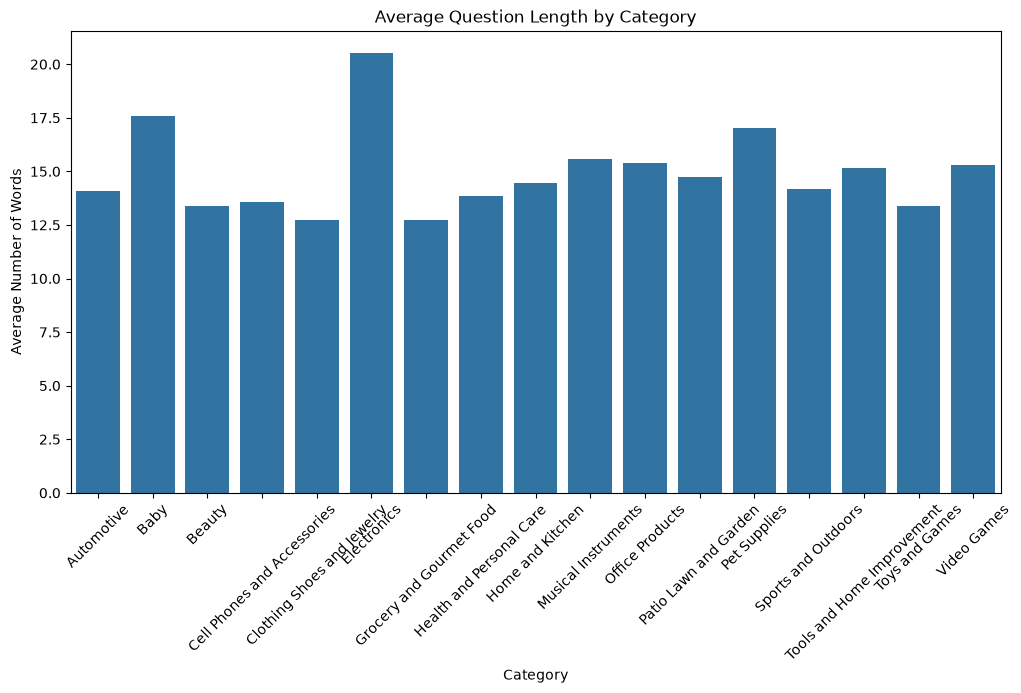

In [39]:
# Calculate the average question length for each category
avg_question_length = (
    dataset
    .groupby("Category")["question_length"]
    .mean()
    .sort_values(ascending=False))

plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_question_length.index,
    y=avg_question_length.values)

plt.title("Average Question Length by Category")
plt.xlabel("Category")
plt.ylabel("Average Number of Words")

plt.xticks(rotation=45)

plt.show()

In [40]:
# Calculate the correlation matrix
correlation = dataset[
    ["question_length", "answer_length"]].corr()

correlation

,question_length,answer_length
question_length,1.000000,0.082712
answer_length,0.082712,1.000000


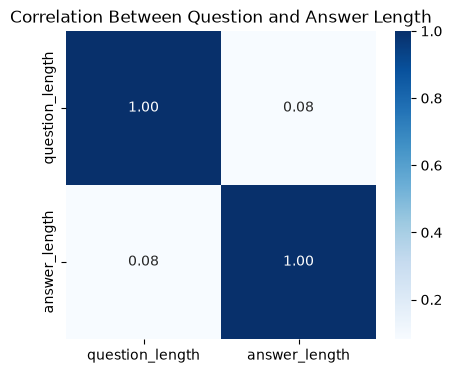

In [41]:
# Visualize the correlation matrix
plt.figure(figsize=(5, 4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f")

plt.title("Correlation Between Question and Answer Length")

plt.show()

In [48]:
# =============================================================================
# Save the processed dataset
# =============================================================================
dataset.to_csv("cleaned_dataset.csv",index=False)